In [ ]:
!pip install pandas


In [ ]:
import pandas as pd

In [ ]:
partido_df = pd.read_csv('/content/qatar.csv', encoding='latin1')
display(partido_df.head())

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361


In [ ]:
total = pd.concat([partido_df['1'], partido_df['2']]).nunique()
print(total)

32


In [ ]:
print(len(partido_df))

64


In [ ]:
print(partido_df['group'].nunique())

13


In [ ]:
print(partido_df['attendance'].mean())

53191.4375


In [ ]:
partido_max = partido_df.loc[(partido_df['1_goals'] - partido_df['2_goals']).abs().idxmax()]
print(f"Partido: {partido_max['1']} vs {partido_max['2']} | Marcador: {partido_max['score']}")


Partido: SPAIN vs COSTA RICA | Marcador: 7,0


In [ ]:
total_penalties_by_team = partido_df.groupby('1')['1_panelties_scored'].sum().add(partido_df.groupby('2')['2_panelties_scored'].sum(), fill_value=0)
print(total_penalties_by_team.idxmax())

ARGENTINA


In [ ]:
penalites_conceded_by_1 = partido_df.groupby('1')['2_panelties_scored'].sum()
penalites_conceded_by_2 = partido_df.groupby('2')['1_panelties_scored'].sum()
total_penalties_conceded_by_team = penalites_conceded_by_1.add(penalites_conceded_by_2, fill_value=0)
print(total_penalties_conceded_by_team.idxmax())

FRANCE


In [ ]:
equipo : str = "ARGENTINA"

In [ ]:
filtroLocal = partido_df['1'] == equipo
partidos_argentina_local = partido_df[filtroLocal]
display(partidos_argentina_local)

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,0,4,5,0,0,63,79,220,327
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,0,5,14,1,0,67,73,240,453
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,1,2,11,21,0,0,87,104,280,409


In [ ]:
filtroVisitante : pd.Series = partido_df['2'] == equipo
partidos_argentina_visitante = partido_df[filtroVisitante]
display(partidos_argentina_visitante)

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,0,25,4,0,0,67,48,438,141
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,0,1,15,5,0,0,91,79,401,323


In [ ]:
partidos : pd.DataFrame = partido_df[filtroLocal | filtroVisitante]
display(partidos)

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,0,4,5,0,0,63,79,220,327
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,0,25,4,0,0,67,48,438,141
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,0,5,14,1,0,67,73,240,453
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,0,1,15,5,0,0,91,79,401,323
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,1,2,11,21,0,0,87,104,280,409


In [ ]:
goles_local = partidos[partidos['1'] == equipo]['1_goals'].sum()
goles_vistante = partidos[partidos['2'] == equipo]['2_goals'].sum()
goles : int = goles_local + goles_vistante
print(goles)

15


In [ ]:
goles_promedio = goles / len(partidos)
print(f"{goles_promedio:.2f}")

2.14


In [ ]:
ganados_local = partidos[(partidos['1'] == equipo) & (partidos['1_goals'] > partidos['2_goals'])].shape[0]
ganados_visitante = partidos[(partidos['2'] == equipo) & (partidos['2_goals'] > partidos['1_goals'])].shape[0]
ganados : int = ganados_local + ganados_visitante
print(ganados)

4


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt

argentina_df = partido_df[
    (partido_df['1'] == 'ARGENTINA') |
    (partido_df['2'] == 'ARGENTINA')
].copy()

argentina_df['partido'] = argentina_df.apply(
    lambda r: f"vs {r['2']}" if r['1'] == 'ARGENTINA' else f"vs {r['1']}",
    axis=1
)

for i, partido in enumerate(argentina_df['partido']):
    print(f"Text({i}, 0, '{partido}')")

Text(0, 0, 'vs SAUDI ARABIA')
Text(1, 0, 'vs MEXICO')
Text(2, 0, 'vs POLAND')
Text(3, 0, 'vs AUSTRALIA')
Text(4, 0, 'vs NETHERLANDS')
Text(5, 0, 'vs CROATIA')
Text(6, 0, 'vs FRANCE')


In [ ]:
goles_como_local = partido_df.groupby('1')['1_goals'].sum()
goles_como_visitante = partido_df.groupby('2')['2_goals'].sum()

goles_totales = goles_como_local.add(goles_como_visitante, fill_value=0).astype(int)
goles_totales = goles_totales.sort_values(ascending=False)

display(goles_totales)

,0
1,
FRANCE,16
ARGENTINA,15
ENGLAND,13
PORTUGAL,12
NETHERLANDS,10
SPAIN,9
CROATIA,8
BRAZIL,8
MOROCCO,6


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31],
 [Text(0, 0, 'FRANCE'),
  Text(1, 0, 'ARGENTINA'),
  Text(2, 0, 'ENGLAND'),
  Text(3, 0, 'PORTUGAL'),
  Text(4, 0, 'NETHERLANDS'),
  Text(5, 0, 'SPAIN'),
  Text(6, 0, 'CROATIA'),
  Text(7, 0, 'BRAZIL'),
  Text(8, 0, 'MOROCCO'),
  Text(9, 0, 'GERMANY'),
  Text(10, 0, 'SERBIA'),
  Text(11, 0, 'SWITZERLAND'),
  Text(12, 0, 'KOREA REPUBLIC'),
  Text(13, 0, 'SENEGAL'),
  Text(14, 0, 'GHANA'),
  Text(15, 0, 'JAPAN'),
  Text(16, 0, 'CAMEROON'),
  Text(17, 0, 'IRAN'),
  Text(18, 0, 'ECUADOR'),
  Text(19, 0, 'AUSTRALIA'),
  Text(20, 0, 'UNITED STATES'),
  Text(21, 0, 'SAUDI ARABIA'),
  Text(22, 0, 'POLAND'),
  Text(23, 0, 'COSTA RICA'),
  Text(24, 0, 'URUGUAY'),
  Text(25, 0, 'MEXICO'),
  Text(26, 0, 'CANADA'),
  Text(27, 0, 'BELGIUM'),
  Text(28, 0, 'DENMARK'),
  Text(29, 0, 'QATAR'),
  Text(30, 0, 'TUNISIA'),
  T

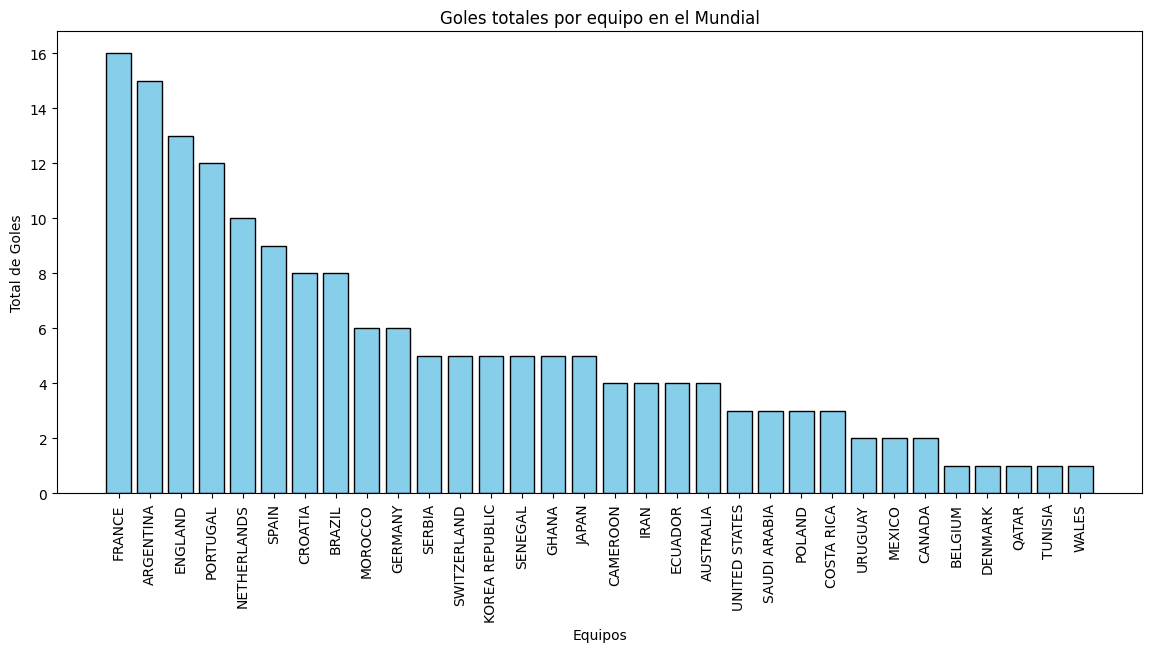

In [ ]:
import matplotlib.pyplot as plt


goles_como_local = partido_df.groupby('1')['1_goals'].sum()
goles_como_visitante = partido_df.groupby('2')['2_goals'].sum()

goles_totales = goles_como_local.add(goles_como_visitante, fill_value=0).astype(int)
goles_totales = goles_totales.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(goles_totales.index, goles_totales.values, color='skyblue', edgecolor='black')

ax.set_title('Goles totales por equipo en el Mundial')
ax.set_xlabel('Equipos')
ax.set_ylabel('Total de Goles')

plt.xticks(rotation=90)

In [ ]:
goles_como_local = partido_df.groupby('1')['1_goals'].sum()
goles_como_visitante = partido_df.groupby('2')['2_goals'].sum()

goles_totales = goles_como_local.add(goles_como_visitante, fill_value=0)

print(goles_totales.idxmax())

FRANCE


In [ ]:
partido_df['partido'] = partido_df['1'] + ' vs ' + partido_df['2']

partido_df['diferencia_goles'] = (partido_df['1_goals'] - partido_df['2_goals']).abs()

display(partido_df[['partido', 'diferencia_goles']])

,partido,diferencia_goles
0,QATAR vs ECUADOR,2
1,ENGLAND vs IRAN,4
2,SENEGAL vs NETHERLANDS,2
3,UNITED STATES vs WALES,0
4,ARGENTINA vs SAUDI ARABIA,1
...,...,...
59,ENGLAND vs FRANCE,1
60,ARGENTINA vs CROATIA,3
61,FRANCE vs MOROCCO,2
62,CROATIA vs MOROCCO,1


In [ ]:
def obtener_ganador(row):
    if row['1_goals'] > row['2_goals']:
        return row['1']
    elif row['2_goals'] > row['1_goals']:
        return row['2']
    else:
        if 'Group' in row['group']:
            return 'Empate'

        match_no = row['match_no']

        if match_no == 53: return 'CROATIA'
        if match_no == 55: return 'MOROCCO'
        if match_no == 57: return 'CROATIA'
        if match_no == 58: return 'ARGENTINA'
        if match_no == 64: return 'ARGENTINA'

        return 'Empate'


partido_df['partido'] = partido_df['1'] + ' vs ' + partido_df['2']
partido_df['ganador'] = partido_df.apply(obtener_ganador, axis=1)

display(partido_df[['partido', 'ganador']])

,partido,ganador
0,QATAR vs ECUADOR,ECUADOR
1,ENGLAND vs IRAN,ENGLAND
2,SENEGAL vs NETHERLANDS,NETHERLANDS
3,UNITED STATES vs WALES,Empate
4,ARGENTINA vs SAUDI ARABIA,SAUDI ARABIA
...,...,...
59,ENGLAND vs FRANCE,FRANCE
60,ARGENTINA vs CROATIA,ARGENTINA
61,FRANCE vs MOROCCO,FRANCE
62,CROATIA vs MOROCCO,CROATIA


In [ ]:
def mapear_fase(group):
    if 'Group' in group:
        return '1. Fase de Grupos'
    elif group == 'Round of 16':
        return '2. Octavos de Final'
    elif group == 'Quarter-final':
        return '3. Cuartos de Final'
    elif group == 'Semi-Final':
        return '4. Semifinales'
    elif group == 'Play-off for third place':
        return '5. Tercer Puesto'
    elif group == 'Final':
        return '6. Final'
    return group


partido_df['fase'] = partido_df['group'].apply(mapear_fase)

goles_1 = partido_df.groupby(['fase', '1'])['1_goals'].sum().reset_index().rename(
    columns={'1': 'equipo', '1_goals': 'goles'}
)

goles_2 = partido_df.groupby(['fase', '2'])['2_goals'].sum().reset_index().rename(
    columns={'2': 'equipo', '2_goals': 'goles'}
)

goles_fase = pd.concat([goles_1, goles_2]).groupby(
    ['fase', 'equipo']
)['goles'].sum().reset_index()

max_goles = goles_fase.groupby('fase')['goles'].transform(max)

goles_maximos = goles_fase[goles_fase['goles'] == max_goles].sort_values('fase')

display(goles_maximos)

/tmp/ipykernel_11068/1126736521.py:31: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  max_goles = goles_fase.groupby('fase')['goles'].transform(max)


,fase,equipo,goles
10,1. Fase de Grupos,ENGLAND,9
26,1. Fase de Grupos,SPAIN,9
43,2. Octavos de Final,PORTUGAL,6
48,3. Cuartos de Final,ARGENTINA,2
52,3. Cuartos de Final,FRANCE,2
54,3. Cuartos de Final,NETHERLANDS,2
56,4. Semifinales,ARGENTINA,3
60,5. Tercer Puesto,CROATIA,2
62,6. Final,ARGENTINA,3
63,6. Final,FRANCE,3
